In [110]:
import pandas as pd

# Load the Excel file
df = pd.read_excel("TAWE_Factors_Data_Reviewed.xlsx")


# One-hot columns start from column 8 (index 7)
one_hot_cols = df.columns[4:10]

# --- View shape ---
print("DataFrame shape:", df.shape)

# --- View head ---
print("\nDataFrame head:")
print(df.head())

# --- Duplicate check for Topic Quote ---
duplicate_quotes = df[df['Topic Quote'].duplicated(keep=False)]

print("\nNumber of duplicate Topic Quotes:", duplicate_quotes.shape[0])
print("\nDuplicate Quotes:")
print(duplicate_quotes[['Topic Quote', 'Quote Number', 'Participant Number']])


DataFrame shape: (212, 10)

DataFrame head:
                                         Topic Quote  Quote Number  \
0  But I think just keeping in mind that not that...         183.0   
1  something that allows it to, or the people usi...         184.0   
2  I suppose, obviously designing an AI, just alw...         185.0   
3  AI, listen, I'm all for it. I'm all for artifi...         186.0   
4  artificial intelligence it takes a lot of the ...         186.0   

   Participant Number     Category - L1  Adaptability  Intent to use  \
0                   2  Technology Trust           1.0            NaN   
1                   2  Technology Trust           1.0            NaN   
2                   9  Technology Trust           1.0            NaN   
3                   9  Technology Trust           NaN            NaN   
4                   9  Technology Trust           NaN            NaN   

   System Performance  System Understanding  Openness to Experimentation  \
0                 NaN     

In [89]:
# Basic stats
num_quotes = df.shape[0]
num_participants = df['Participant Number'].nunique()

# Frequency of main categories
category_counts = df['Category - L1'].value_counts()

# --- FIX: convert one-hot columns to numeric ---
df[one_hot_cols] = df[one_hot_cols].apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)

# Count of 1s in one-hot columns
one_hot_counts = df[one_hot_cols].sum().sort_values(ascending=False)

# Quotes per participant
quotes_per_participant = df.groupby('Participant Number')['Quote Number'].count()

# Display results
print("Total quotes:", num_quotes)
print("Total participants:", num_participants)

print("\nCategory counts:\n", category_counts)

print("\nOne-hot column counts:\n", one_hot_counts)

print("\nQuotes per participant:\n", quotes_per_participant)


Total quotes: 212
Total participants: 10

Category counts:
 Category - L1
Technology Trust    212
Name: count, dtype: int64

One-hot column counts:
 Percieved Usefulness           132
System Understanding           102
Adaptability                    78
System Performance              71
Openness to Experimentation     21
Intent to use                   17
dtype: int64

Quotes per participant:
 Participant Number
1     17
10    24
2     27
3     17
4     23
5     21
6     20
7     19
8     22
9     21
Name: Quote Number, dtype: int64


In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

# --- 1. Ensure data types ---
df['Topic Quote'] = df['Topic Quote'].astype(str)
df = df.dropna(subset=['Participant Number'])
df['Participant Number'] = df['Participant Number'].astype(str)

# --- 2. Identify one-hot factor columns ---
one_hot_cols = df.columns[4:10]  # adjust if necessary

# --- 3. Compute sentiment for each quote ---
df['Sentiment'] = df['Topic Quote'].apply(lambda x: TextBlob(x).sentiment.polarity)

# --- 4. Compute mean sentiment per participant per factor ---
all_participants = df['Participant Number'].unique()
participant_sentiment = {p: {} for p in all_participants}

for participant in all_participants:
    participant_data = df[df['Participant Number'] == participant]
    
    for col in one_hot_cols:
        subset = participant_data[participant_data[col] == 1]['Sentiment']
        participant_sentiment[participant][col] = subset.mean() if not subset.empty else np.nan

participant_sentiment_df = pd.DataFrame(participant_sentiment).T
print("Mean sentiment per participant per factor:")
print(participant_sentiment_df)

# --- 5. Compute overall descriptive stats per factor ---
overall_stats = pd.DataFrame(index=one_hot_cols, columns=['mean', 'std', 'min', 'max', 'mode', 'count'])

for col in one_hot_cols:
    data = participant_sentiment_df[col].dropna()
    if not data.empty:
        overall_stats.loc[col, 'mean'] = data.mean()
        overall_stats.loc[col, 'std'] = data.std()
        overall_stats.loc[col, 'min'] = data.min()
        overall_stats.loc[col, 'max'] = data.max()
        overall_stats.loc[col, 'mode'] = data.mode().iloc[0] if not data.mode().empty else np.nan
        overall_stats.loc[col, 'count'] = data.nunique()
    else:
        overall_stats.loc[col] = [np.nan]*6

print("\nOverall descriptive stats per factor:")
print(overall_stats)

# --- 6. Compute weighted Technology Trust ---
weights = [0.25, 0.15, 0.2, 0.1, 0.15, 0.15]  # adjust based on factor importance
factor_cols = participant_sentiment_df.columns[:6]
assert np.isclose(sum(weights), 1), "Weights must sum to 1"

participant_sentiment_df['TechTrust'] = participant_sentiment_df[factor_cols].mul(weights).sum(axis=1)
print("\nWeighted Technology Trust per participant:")
print(participant_sentiment_df[['TechTrust']])

# --- 7. Bootstrapping Technology Trust ---
n_boot = 10000
boot_means = []
techtrust_values = participant_sentiment_df['TechTrust'].dropna().values

for _ in range(n_boot):
    sample = np.random.choice(techtrust_values, size=len(techtrust_values), replace=True)
    boot_means.append(np.mean(sample))

boot_means = np.array(boot_means)
ci_lower = np.percentile(boot_means, 2.5)
ci_upper = np.percentile(boot_means, 97.5)
boot_mean = np.mean(boot_means)

print(f"\nBootstrap mean TechTrust: {boot_mean:.3f}")
print(f"95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]")


Mean sentiment per participant per factor:
    Adaptability  Intent to use  System Performance  System Understanding  \
2       0.063393            NaN            0.048750              0.131424   
9       0.037732       0.124074            0.060938              0.105289   
7       0.263667       0.000000            0.222222              0.261875   
6       0.000000       0.054167            0.214583              0.205000   
8       0.085056       0.080556            0.081486              0.073427   
1       0.142545       0.101091            0.118183              0.206481   
4       0.101243       0.175260            0.077500              0.152394   
3       0.068079            NaN           -0.007444              0.200185   
10      0.271854       0.101505            0.049840              0.194930   
5       0.094577       0.111111            0.048889              0.120090   

    Openness to Experimentation  Percieved Usefulness  
2                      0.000000              0.063393

In [100]:
participant_sentiment_df.columns

Index(['Adaptability', 'Intent to use', 'System Performance',
       'System Understanding', 'Openness to Experimentation',
       'Percieved Usefulness', 'TechTrust'],
      dtype='object')

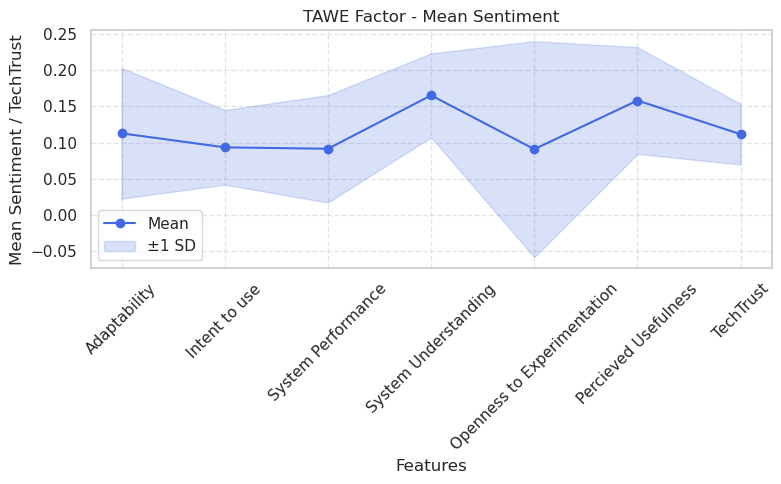

In [107]:
import matplotlib.pyplot as plt
import numpy as np

# Features
features = ['Adaptability', 'Intent to use', 'System Performance',
            'System Understanding', 'Openness to Experimentation',
            'Percieved Usefulness', 'TechTrust']

# Compute mean and standard deviation per feature
mean_values = participant_sentiment_df[features].mean()
std_values = participant_sentiment_df[features].std()

# Scree-style plot with error bars (shaded area)
plt.figure(figsize=(8,5))
x = np.arange(1, len(features)+1)

plt.plot(x, mean_values.values, marker='o', linestyle='-', color='royalblue', label='Mean')
plt.fill_between(x, mean_values - std_values, mean_values + std_values, color='royalblue', alpha=0.2, label='±1 SD')

plt.xticks(x, features, rotation=45)
plt.title("TAWE Factor - Mean Sentiment")
plt.xlabel("Features")
plt.ylabel("Mean Sentiment / TechTrust")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


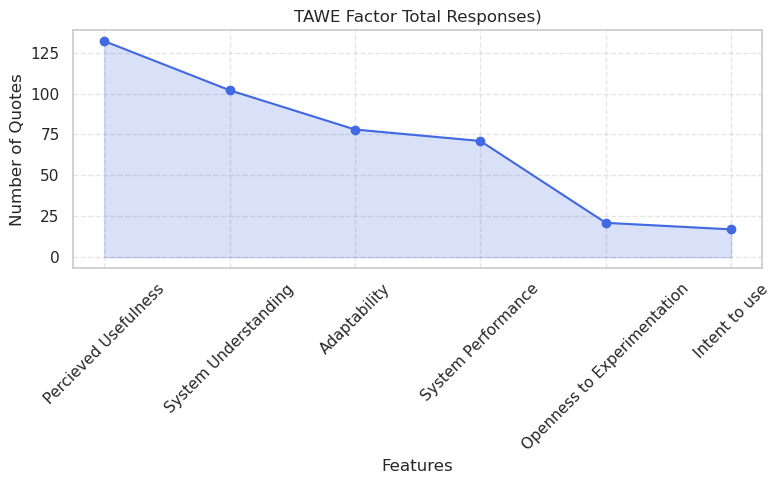

In [109]:
import matplotlib.pyplot as plt
import numpy as np

# one_hot_counts is already computed
features = one_hot_counts.index
counts = one_hot_counts.values

plt.figure(figsize=(8,5))
x = np.arange(1, len(features)+1)

plt.plot(x, counts, marker='o', linestyle='-', color='royalblue', label='Number of Quotes')
plt.fill_between(x, counts, color='royalblue', alpha=0.2)

plt.xticks(x, features, rotation=45)
plt.title("TAWE Factor Total Responses)")
plt.xlabel("Features")
plt.ylabel("Number of Quotes")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



In [92]:
from scipy.stats import shapiro, anderson
import statsmodels.api as sm

normality_results = []

for col in factor_cols:
    data = participant_sentiment_df[col].dropna()
    
    if len(data) < 3:
        normality_results.append([col, np.nan, np.nan, "Too few values"])
        continue

    # --- Shapiro-Wilk ---
    sw_stat, sw_p = shapiro(data)
    sw_interp = "Normal" if sw_p > 0.05 else "Not normal"
    
    # --- Anderson-Darling ---
    ad_result = anderson(data)
    ad_stat = ad_result.statistic
    critical_5pct = ad_result.critical_values[2]  # index 2 = 5% level
    ad_interp = "Normal" if ad_stat < critical_5pct else "Not normal"

    normality_results.append([
        col, sw_stat, sw_p, sw_interp, ad_stat, ad_interp
    ])

    

normality_df = pd.DataFrame(
    normality_results,
    columns=["Factor", "SW W", "SW p", "Shapiro Interpretation",
             "AD Statistic", "AD Interpretation"]
)

print("\n=== Normality Tests (Shapiro + Anderson) ===")
print(normality_df)


=== Normality Tests (Shapiro + Anderson) ===
                        Factor      SW W      SW p Shapiro Interpretation  \
0                 Adaptability  0.868181  0.095197                 Normal   
1                Intent to use  0.963352  0.841355                 Normal   
2           System Performance  0.857583  0.071456                 Normal   
3         System Understanding  0.957563  0.757763                 Normal   
4  Openness to Experimentation  0.853707  0.064289                 Normal   
5         Percieved Usefulness  0.900622  0.222569                 Normal   

   AD Statistic AD Interpretation  
0      0.626354            Normal  
1      0.265774            Normal  
2      0.710413        Not normal  
3      0.283206            Normal  
4      0.680415            Normal  
5      0.465350            Normal  


In [96]:
# --- 8. Visualizations ---
# Correlation analysis between factors

factor_data = participant_sentiment_df[factor_cols].astype(float)

# --- 8a. Pearson and Spearman correlations with p-values ---
pearson_results = pd.DataFrame(index=factor_cols, columns=factor_cols)
pearson_pvals = pd.DataFrame(index=factor_cols, columns=factor_cols)
spearman_results = pd.DataFrame(index=factor_cols, columns=factor_cols)
spearman_pvals = pd.DataFrame(index=factor_cols, columns=factor_cols)

for i, f1 in enumerate(factor_cols):
    for j, f2 in enumerate(factor_cols):
        x = factor_data[f1].dropna()
        y = factor_data[f2].dropna()
        # Align lengths
        common_idx = x.index.intersection(y.index)
        x = x.loc[common_idx]
        y = y.loc[common_idx]
        
        if len(x) > 1:
            # Pearson
            r, p = pearsonr(x, y)
            pearson_results.loc[f1, f2] = r
            pearson_pvals.loc[f1, f2] = p
            # Spearman
            r_s, p_s = spearmanr(x, y)
            spearman_results.loc[f1, f2] = r_s
            spearman_pvals.loc[f1, f2] = p_s
        else:
            pearson_results.loc[f1, f2] = np.nan
            pearson_pvals.loc[f1, f2] = np.nan
            spearman_results.loc[f1, f2] = np.nan
            spearman_pvals.loc[f1, f2] = np.nan

print("\nPearson correlation matrix:")
print(pearson_results.astype(float).round(3))
print("\nPearson p-values:")
print(pearson_pvals.astype(float).round(3))

print("\nSpearman correlation matrix:")
print(spearman_results.astype(float).round(3))
print("\nSpearman p-values:")
print(spearman_pvals.astype(float).round(3))



Pearson correlation matrix:
                             Adaptability  Intent to use  System Performance  \
Adaptability                        1.000         -0.322               0.168   
Intent to use                      -0.322          1.000              -0.779   
System Performance                  0.168         -0.779               1.000   
System Understanding                0.516         -0.553               0.525   
Openness to Experimentation        -0.305         -0.158              -0.055   
Percieved Usefulness                0.714         -0.756               0.600   

                             System Understanding  \
Adaptability                                0.516   
Intent to use                              -0.553   
System Performance                          0.525   
System Understanding                        1.000   
Openness to Experimentation                -0.122   
Percieved Usefulness                        0.718   

                             Openness 

In [98]:
# --- 8. Visualizations ---
# Correlation analysis between factors

factor_data = participant_sentiment_df[factor_cols].astype(float)

# --- Pearson correlations and p-values ---
pearson_results = pd.DataFrame(index=factor_cols, columns=factor_cols, dtype=float)
pearson_pvals = pd.DataFrame(index=factor_cols, columns=factor_cols, dtype=float)

for f1 in factor_cols:
    for f2 in factor_cols:
        if f1 == f2:
            # Set diagonal to perfect correlation and p-value = 0
            pearson_results.loc[f1, f2] = 1.0
            pearson_pvals.loc[f1, f2] = 0.0
            continue
        
        x = factor_data[f1].dropna()
        y = factor_data[f2].dropna()

        # Align indices
        common_idx = x.index.intersection(y.index)
        x = x.loc[common_idx]
        y = y.loc[common_idx]

        if len(x) > 1:
            r, p = pearsonr(x, y)
            pearson_results.loc[f1, f2] = r
            pearson_pvals.loc[f1, f2] = p
        else:
            pearson_results.loc[f1, f2] = np.nan
            pearson_pvals.loc[f1, f2] = np.nan

# --- Display basic matrices ---
print("\nPearson correlation matrix:")
print(pearson_results.round(3))

print("\nPearson p-values:")
print(pearson_pvals.round(3))

# ==========================================================
# === SIGNIFICANCE HIGHLIGHTED CORRELATION MATRIX (TEXT) ===
# ==========================================================

highlighted = pearson_results.copy().astype(object)

for row in factor_cols:
    for col in factor_cols:
        r = pearson_results.loc[row, col]
        p = pearson_pvals.loc[row, col]

        if pd.isna(r):
            highlighted.loc[row, col] = ""
        else:
            if row == col:
                highlighted.loc[row, col] = "1.000"
            elif p < 0.05:
                highlighted.loc[row, col] = f"{r:.3f} ***"
            else:
                highlighted.loc[row, col] = f"{r:.3f}"

print("\n=== Pearson Correlation Matrix (Significance Highlighted) ===")
print(highlighted)

# ==========================================================
# === OPTIONAL: COLORED MATRIX USING PANDAS STYLER =========
# ==========================================================

def highlight_sig(val):
    """Color cells yellow when significant."""
    if isinstance(val, str) and "***" in val:
        return "background-color: yellow"
    return ""

styled_highlighted = highlighted.style.applymap(highlight_sig)

styled_highlighted



Pearson correlation matrix:
                             Adaptability  Intent to use  System Performance  \
Adaptability                        1.000         -0.322               0.168   
Intent to use                      -0.322          1.000              -0.779   
System Performance                  0.168         -0.779               1.000   
System Understanding                0.516         -0.553               0.525   
Openness to Experimentation        -0.305         -0.158              -0.055   
Percieved Usefulness                0.714         -0.756               0.600   

                             System Understanding  \
Adaptability                                0.516   
Intent to use                              -0.553   
System Performance                          0.525   
System Understanding                        1.000   
Openness to Experimentation                -0.122   
Percieved Usefulness                        0.718   

                             Openness 

/tmp/ipykernel_13645/3574478385.py:75: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_highlighted = highlighted.style.applymap(highlight_sig)


,Adaptability,Intent to use,System Performance,System Understanding,Openness to Experimentation,Percieved Usefulness
Adaptability,1.000,-0.322,0.168,0.516,-0.305,0.714 ***
Intent to use,-0.322,1.000,-0.779 ***,-0.553,-0.158,-0.756 ***
System Performance,0.168,-0.779 ***,1.000,0.525,-0.055,0.600
System Understanding,0.516,-0.553,0.525,1.000,-0.122,0.718 ***
Openness to Experimentation,-0.305,-0.158,-0.055,-0.122,1.000,-0.171
Percieved Usefulness,0.714 ***,-0.756 ***,0.600,0.718 ***,-0.171,1.000


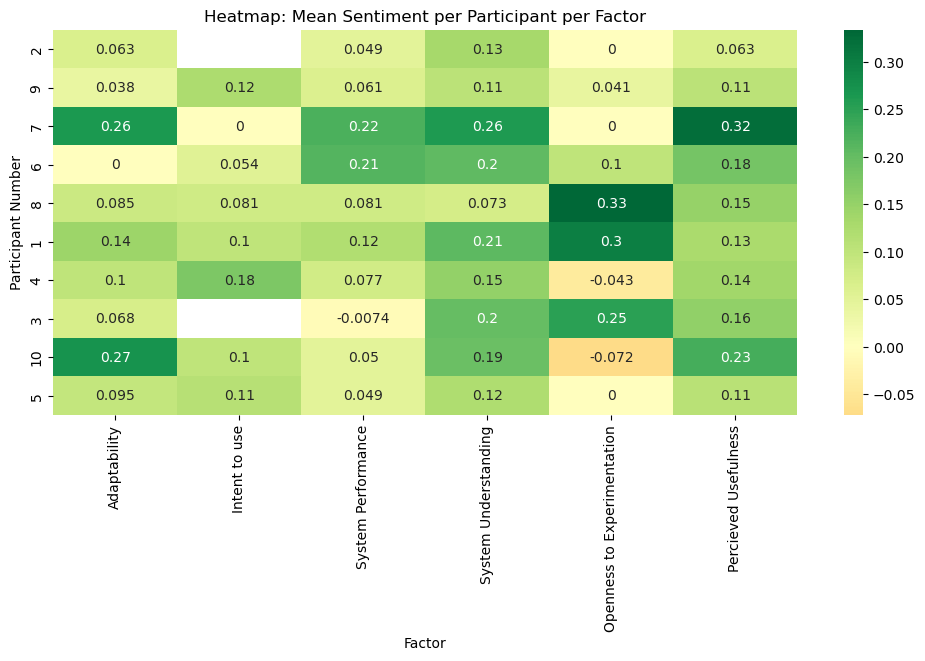

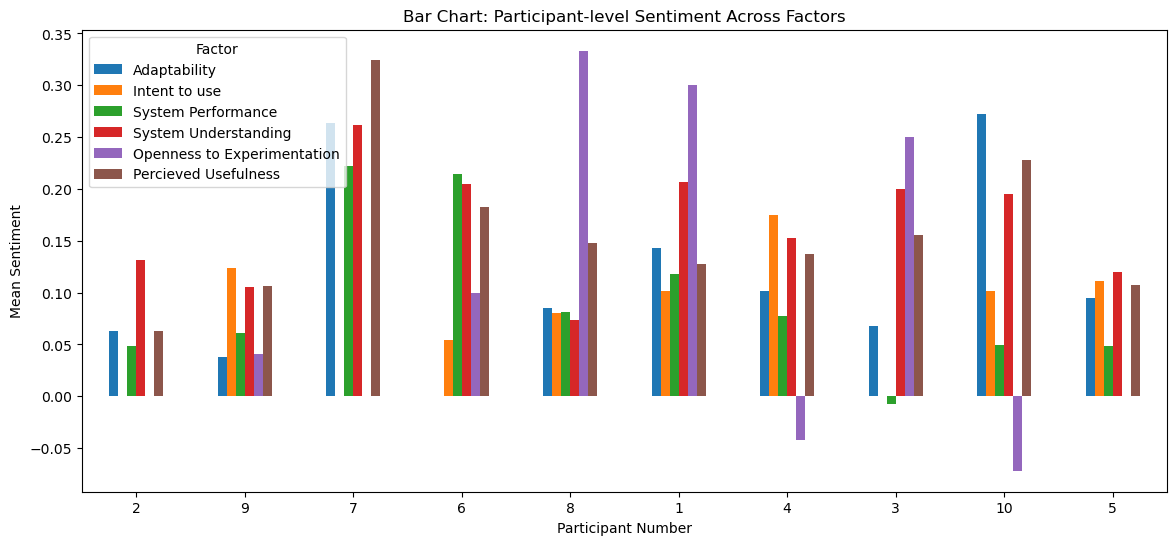

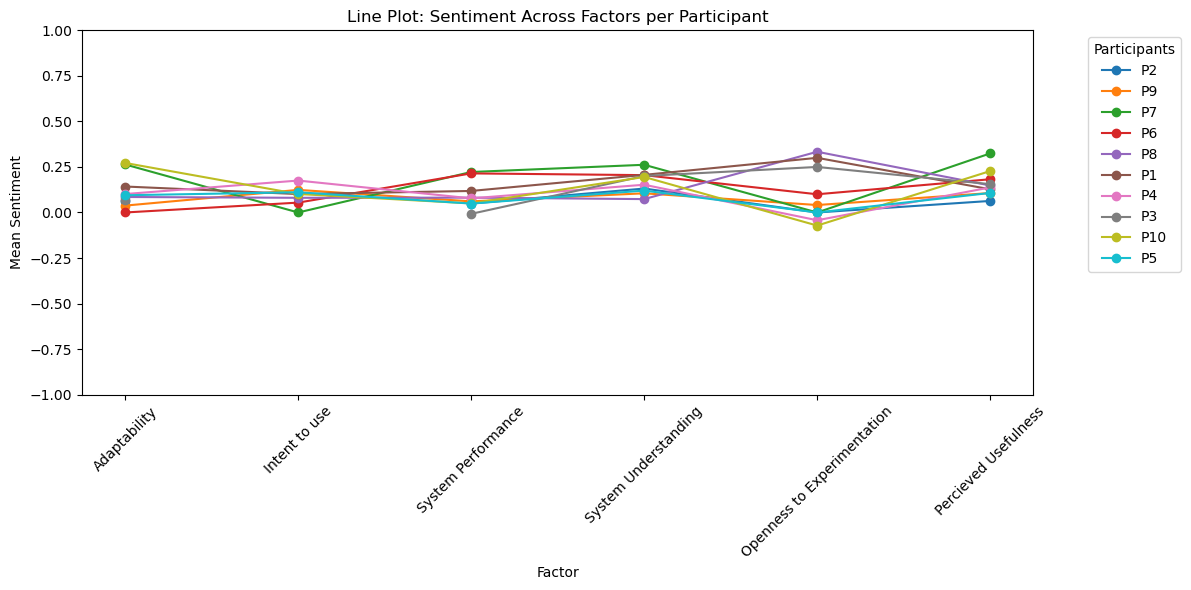

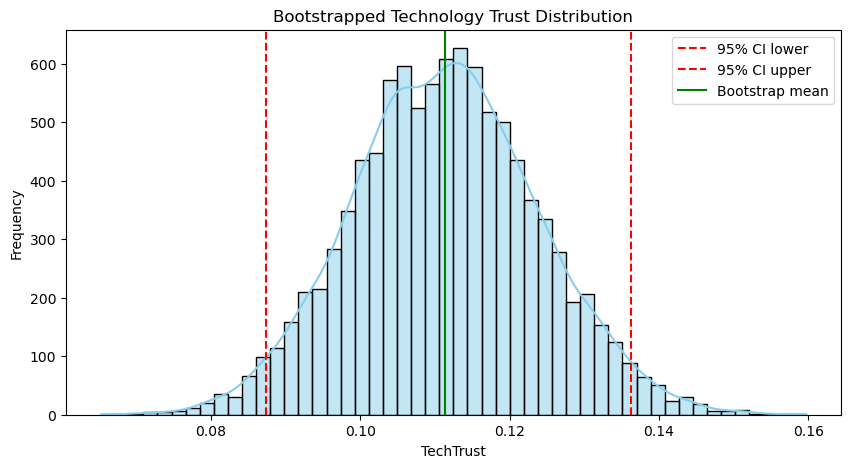

In [94]:
# Heatmap of participant-level sentiment
plt.figure(figsize=(12,5))
sns.heatmap(participant_sentiment_df[factor_cols].astype(float), annot=True, cmap='RdYlGn', center=0)
plt.title("Heatmap: Mean Sentiment per Participant per Factor")
plt.ylabel("Participant Number")
plt.xlabel("Factor")
plt.show()

# Bar chart per participant
participant_sentiment_df[factor_cols].astype(float).plot(kind='bar', figsize=(14,6))
plt.title("Bar Chart: Participant-level Sentiment Across Factors")
plt.ylabel("Mean Sentiment")
plt.xlabel("Participant Number")
plt.xticks(rotation=0)
plt.legend(title="Factor")
plt.show()

# Line plot (“spaghetti plot”) of sentiment across factors
plt.figure(figsize=(12,6))
for idx, row in participant_sentiment_df[factor_cols].iterrows():
    plt.plot(row.index, row.values, marker='o', label=f'P{idx}')
plt.title("Line Plot: Sentiment Across Factors per Participant")
plt.ylabel("Mean Sentiment")
plt.xlabel("Factor")
plt.xticks(rotation=45)
plt.ylim(-1,1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Participants")
plt.tight_layout()
plt.show()

# Histogram of bootstrapped TechTrust
plt.figure(figsize=(10,5))
sns.histplot(boot_means, bins=50, kde=True, color='skyblue')
plt.axvline(ci_lower, color='red', linestyle='--', label='95% CI lower')
plt.axvline(ci_upper, color='red', linestyle='--', label='95% CI upper')
plt.axvline(boot_mean, color='green', linestyle='-', label='Bootstrap mean')
plt.title("Bootstrapped Technology Trust Distribution")
plt.xlabel("TechTrust")
plt.ylabel("Frequency")
plt.legend()
plt.show()


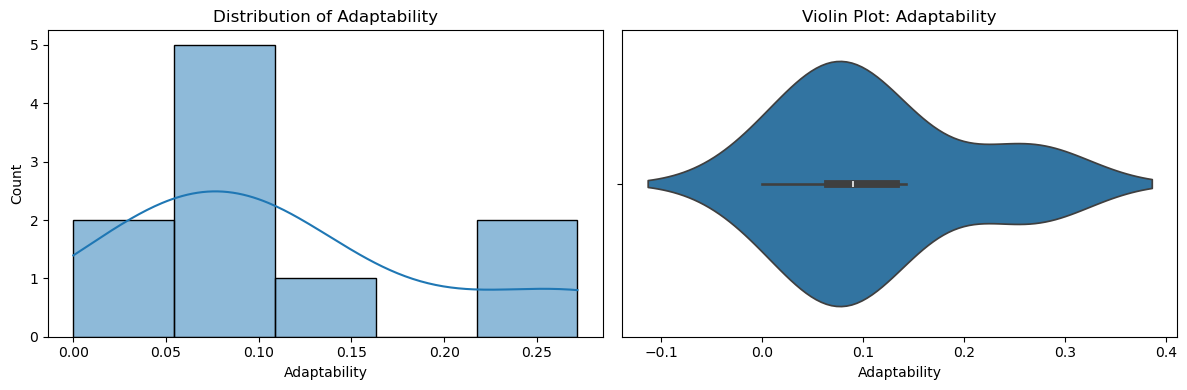

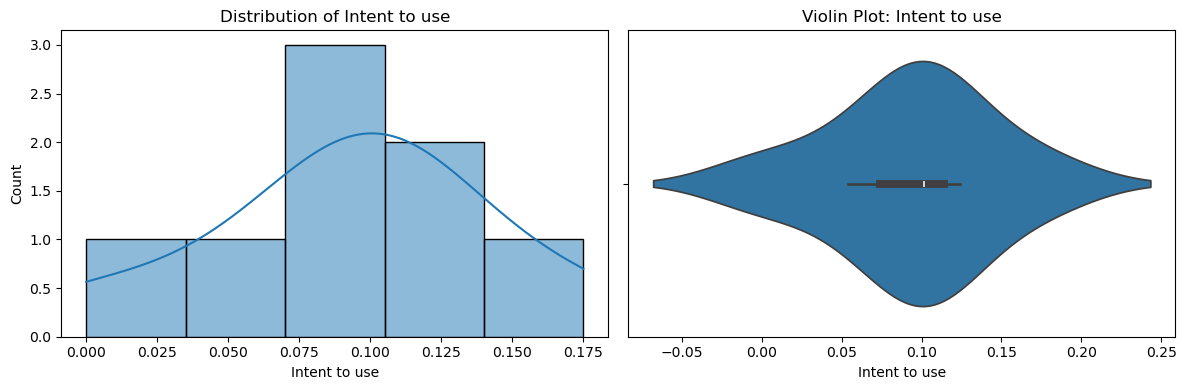

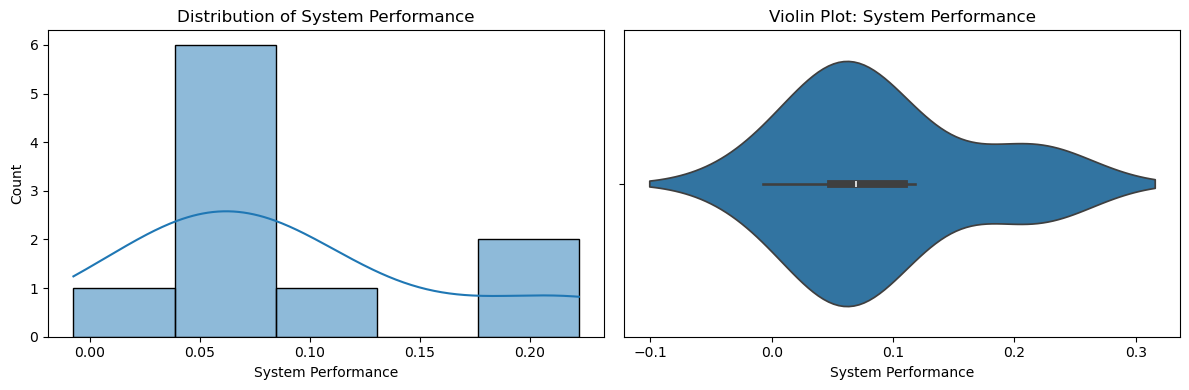

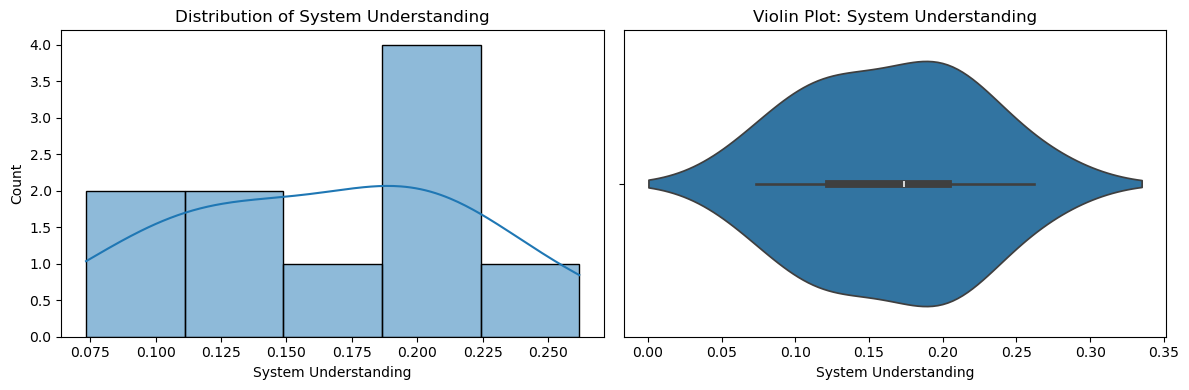

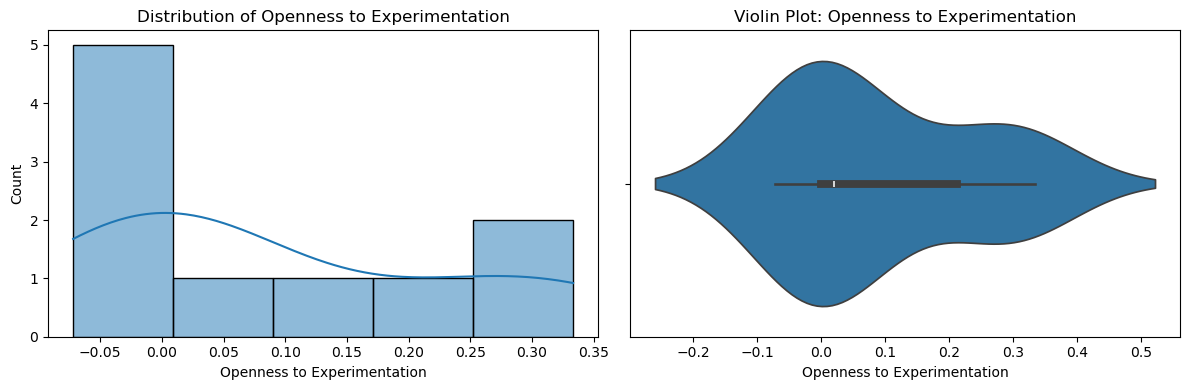

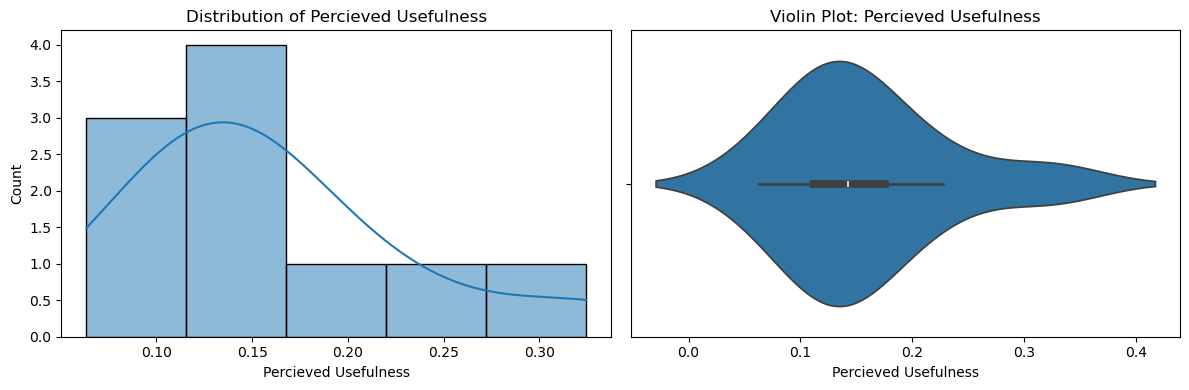

In [95]:
for col in factor_cols:
    data = participant_sentiment_df[col].dropna()

    plt.figure(figsize=(12, 4))

    # Histogram + KDE
    plt.subplot(1, 2, 1)
    sns.histplot(data, kde=True)
    plt.title(f"Distribution of {col}")

    # Violin plot
    plt.subplot(1, 2, 2)
    sns.violinplot(x=data)
    plt.title(f"Violin Plot: {col}")

    plt.tight_layout()
    plt.show()
